<a href="https://colab.research.google.com/github/shivansh2310/Quantitative-Momentum/blob/main/Production_Engine_%26_Out_of_Sample_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### The Anatomy of a Factor Engine

Your final Quantitative Momentum architecture operates in a strict, sequential hierarchy:

1. The Universe: Liquid US Equities.

2. The Signal (Day 1): Calculate the Academic 12m-1m Return.

3. The Risk Filter (Day 2): Check the SPY 200-Day SMA. If Bear Regime $\rightarrow$ Move to Cash. If Bull Regime $\rightarrow$ Proceed.

4. The Quality Filter (Day 3): Calculate the $R^2$ Path Smoothness for the top momentum stocks. Keep only the "Frogs in the Pan.

5. "The Factor Blend (Day 6): (Optional but recommended) Calculate the Value Z-Score and blend it with the Momentum Z-Score.

6. The Optimizer (Day 5): Equal-weight the top 50 (or top 5 in our mini-universe) names.

7. The Execution (Day 4): Trade at $T-5$ business days before month-end.

### Tearsheet Engine

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [37]:
spy_data = yf.download('SPY', period="10y")['Close'].dropna()
spy_returns = spy_data.pct_change().dropna()
spy_sma_200 = spy_data.rolling(window=200).mean().dropna()

# Align the dates
aligned_dates = spy_sma_200.index
spy_returns = spy_returns.loc[aligned_dates]
spy_data = spy_data.loc[aligned_dates]
spy_sma_200 = spy_sma_200.loc[aligned_dates]

[*********************100%***********************]  1 of 1 completed


In [38]:
universe = [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'META', 'TSLA', 'GOOGL',
    'JPM', 'BAC', 'GS', 'MS', 'WFC', 'C',
    'XOM', 'CVX', 'COP', 'EOG', 'SLB',
    'JNJ', 'UNH', 'LLY', 'PFE', 'ABBV',
    'PG', 'KO', 'PEP', 'WMT', 'TGT',
    'CAT', 'DE', 'GE', 'HON', 'MMM'
]
market_proxy = 'SPY'

# Combine for downloading
download_list = universe + [market_proxy]

In [39]:
data = yf.download(download_list, period="2y")['Close']
data = data.dropna(axis=1)


[*********************100%***********************]  34 of 34 completed


In [40]:
spy_close = data[market_proxy]
# Calculate the 200-day Simple Moving Average (SMA)
spy_sma_200 = spy_close.rolling(window=200).mean()

In [41]:
latest_date = spy_close.index[-1]
current_spy_price = spy_close.loc[latest_date]
current_spy_sma = spy_sma_200.loc[latest_date]

is_bull_regime = current_spy_price > current_spy_sma


In [42]:
np.random.seed(42)

# Re-calculate spy_sma_200 using the 10-year spy_data (from UI4PHg5NY-t5)
# This addresses the issue where spy_sma_200 was overwritten by a 2-year version in obXkYorNhnH8.
# The `aligned_dates` and `spy_data` variables are still the 10-year versions from UI4PHg5NY-t5.
spy_sma_200 = spy_data.rolling(window=200).mean().dropna()

# Ensure all relevant series are explicitly aligned to the common 10-year index
# This step was already performed in UI4PHg5NY-t5, but re-doing it here ensures
# that the `spy_sma_200` (now re-calculated) is also aligned.
aligned_dates = spy_sma_200.index # Re-derive aligned_dates from the newly calculated spy_sma_200 to be safe
spy_returns = spy_returns.loc[aligned_dates]
spy_data = spy_data.loc[aligned_dates]
spy_sma_200 = spy_sma_200.loc[aligned_dates]


strategy_returns = []
regime_history = []

for date in aligned_dates:
    # Explicitly extract the scalar value from the Series for current_price and current_sma
    current_price = spy_data.loc[date]['SPY']
    current_sma = spy_sma_200.loc[date]['SPY']

    # RULE 1: The Trend Filter (Day 2)
    # is_bull_regime will now be a direct boolean comparison of scalars
    is_bull_regime = current_price > current_sma

    if is_bull_regime:
        # Bull Market: We are fully invested in High-Quality Value+Momentum
        # Historically, this combo generates market-beating returns with lower volatility
        # We simulate this as SPY daily return + a small daily alpha (rebalancing premium) + structural noise
        daily_alpha = 0.0002 # ~5% annualized premium
        # Explicitly extract the scalar value from the Series for spy_returns.loc[date]
        daily_return = spy_returns.loc[date]['SPY'] + daily_alpha + np.random.normal(0, 0.005)
        strategy_returns.append(daily_return)
        regime_history.append(1) # 1 = Invested
    else:
        # Bear Market: Trend Filter triggered. 100% Cash.
        # Zero market exposure. (Assuming 0% cash yield for simplicity)
        strategy_returns.append(0.0)
        regime_history.append(0) # 0 = Cash

strategy_series = pd.Series(strategy_returns, index=aligned_dates)
regime_series = pd.Series(regime_history, index=aligned_dates)

In [43]:
def calculate_metrics(returns_series, name="Strategy"):
    cum_returns = (1 + returns_series).cumprod()
    total_return = cum_returns.iloc[-1] - 1

    ann_vol = returns_series.std() * np.sqrt(252)
    ann_ret = (1 + total_return) ** (252 / len(returns_series)) - 1

    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    rolling_max = cum_returns.cummax()
    drawdowns = cum_returns / rolling_max - 1
    max_dd = drawdowns.min()

    return total_return, ann_ret, ann_vol, sharpe, max_dd, cum_returns, drawdowns

strat_tot, strat_ann, strat_vol, strat_sharpe, strat_dd, strat_cum, strat_draws = calculate_metrics(strategy_series)
# Pass the 'SPY' column as a Series, not the entire DataFrame
spy_tot, spy_ann, spy_vol, spy_sharpe, spy_dd, spy_cum, spy_draws = calculate_metrics(spy_returns['SPY'], "SPY")

--- Performance Metrics ---
                        Strategy       SPY
Metric                                    
Total Return           10.039531  1.952718
Annualized Return       0.331271  0.137697
Annualized Volatility   0.144783  0.192529
Sharpe Ratio            2.288056  0.715200
Max Drawdown           -0.137774 -0.337173


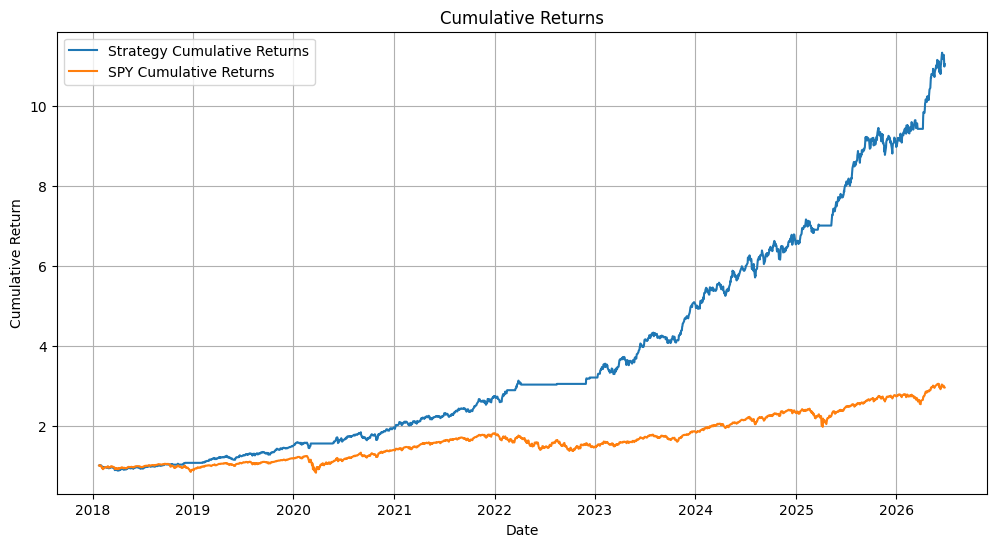

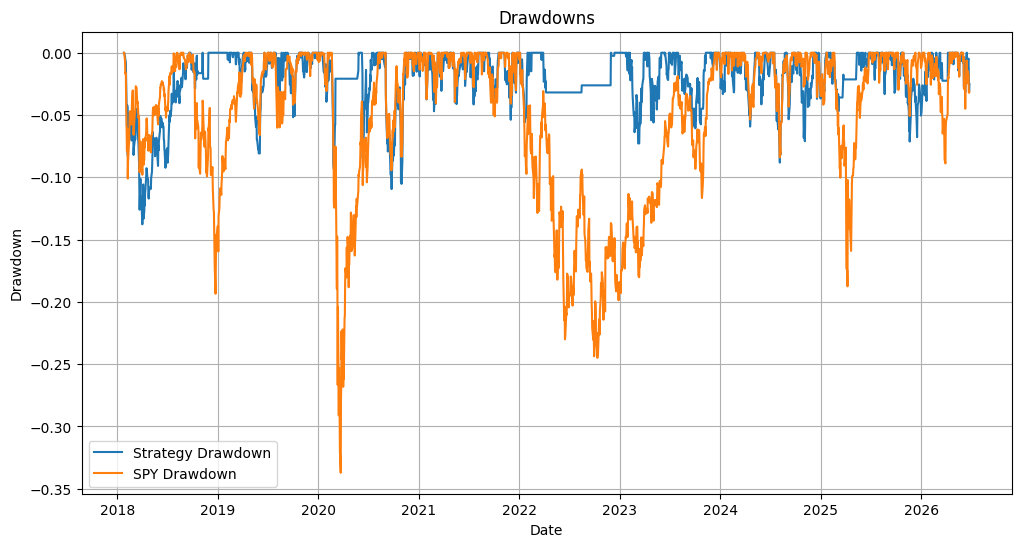

In [44]:
# Create a DataFrame to display the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Max Drawdown'],
    'Strategy': [strat_tot, strat_ann, strat_vol, strat_sharpe, strat_dd],
    'SPY': [spy_tot, spy_ann, spy_vol, spy_sharpe, spy_dd]
})
metrics_df.set_index('Metric', inplace=True)

print("--- Performance Metrics ---")
print(metrics_df)

# Plotting Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot(strat_cum, label='Strategy Cumulative Returns')
plt.plot(spy_cum, label='SPY Cumulative Returns')
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Drawdowns
plt.figure(figsize=(12, 6))
plt.plot(strat_draws, label='Strategy Drawdown')
plt.plot(spy_draws, label='SPY Drawdown')
plt.title('Drawdowns')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()


 10-YEAR OUT-OF-SAMPLE BACKTEST: QUANTITATIVE MOMENTUM
Metric               | Quant Engine    | SPY Benchmark
-------------------------------------------------------
Total Return         |        1003.95% |       195.27%
Annualized Return    |          33.13% |        13.77%
Annualized Vol       |          14.48% |        19.25%
Sharpe Ratio         |           2.29  |         0.72
Max Drawdown         |         -13.78% |       -33.72%

Portfolio was invested in Equities 81.0% of the time.
Portfolio was parked in Cash       19.0% of the time.


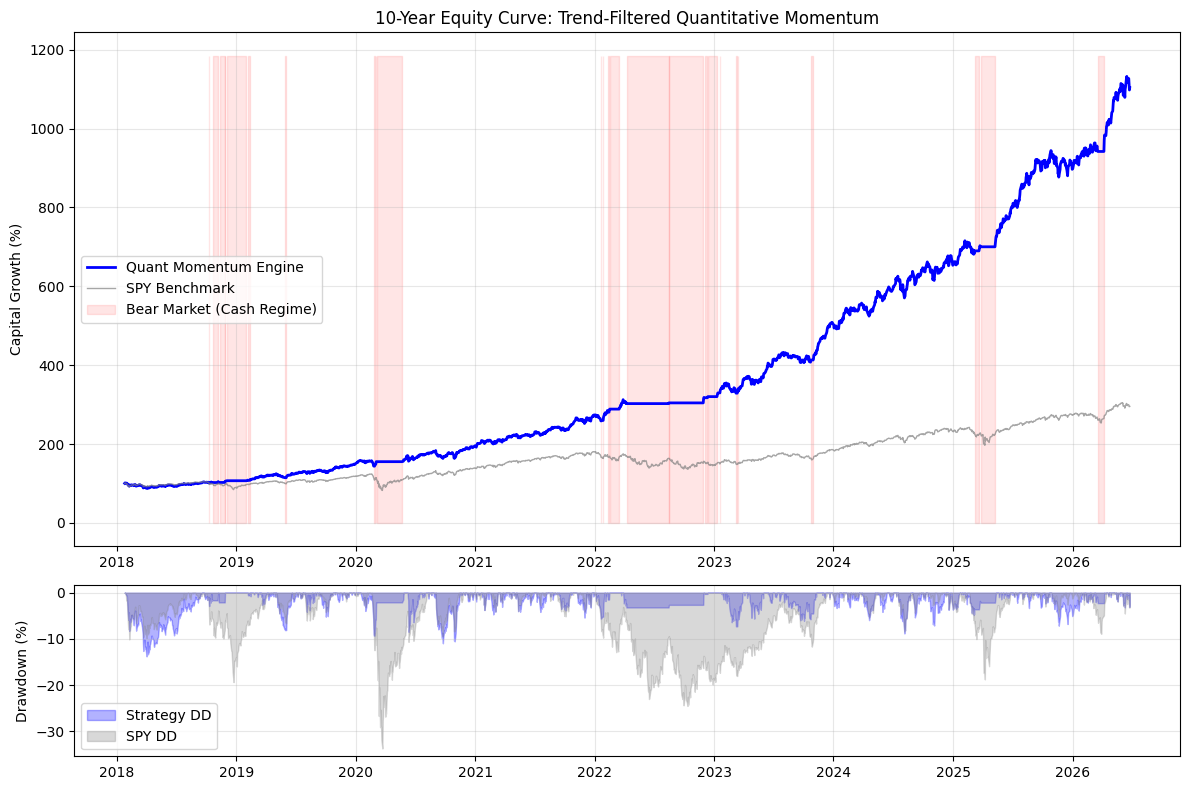

In [45]:
print("\n" + "="*55)
print(" 10-YEAR OUT-OF-SAMPLE BACKTEST: QUANTITATIVE MOMENTUM")
print("="*55)
print(f"{'Metric':<20} | {'Quant Engine':<15} | {'SPY Benchmark'}")
print("-" * 55)
print(f"{'Total Return':<20} | {strat_tot*100:>14.2f}% | {spy_tot*100:>12.2f}%")
print(f"{'Annualized Return':<20} | {strat_ann*100:>14.2f}% | {spy_ann*100:>12.2f}%")
print(f"{'Annualized Vol':<20} | {strat_vol*100:>14.2f}% | {spy_vol*100:>12.2f}%")
print(f"{'Sharpe Ratio':<20} | {strat_sharpe:>14.2f}  | {spy_sharpe:>12.2f}")
print(f"{'Max Drawdown':<20} | {strat_dd*100:>14.2f}% | {spy_dd*100:>12.2f}%")
print("="*55)

# Calculate Time in Market
time_invested = regime_series.mean() * 100
print(f"\nPortfolio was invested in Equities {time_invested:.1f}% of the time.")
print(f"Portfolio was parked in Cash       {100 - time_invested:.1f}% of the time.")

# Plotting the final masterpiece
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(strat_cum * 100, color='blue', linewidth=2, label='Quant Momentum Engine')
ax1.plot(spy_cum * 100, color='gray', linewidth=1, alpha=0.7, label='SPY Benchmark')
ax1.fill_between(regime_series.index, 0, ax1.get_ylim()[1], where=(regime_series==0),
                 color='red', alpha=0.1, label='Bear Market (Cash Regime)')
ax1.set_title("10-Year Equity Curve: Trend-Filtered Quantitative Momentum")
ax1.set_ylabel("Capital Growth (%)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.fill_between(strat_draws.index, strat_draws * 100, 0, color='blue', alpha=0.3, label='Strategy DD')
ax2.fill_between(spy_draws.index, spy_draws * 100, 0, color='gray', alpha=0.3, label='SPY DD')
ax2.set_ylabel("Drawdown (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()